<a href="https://colab.research.google.com/github/Kotha-Divya/Seasonal-Agriculture-Performance-Analysis-/blob/main/Seasonal_Agriculture_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Seasonal Agriculture Performance**

**Major Data Analytics Project**

**Domain**: Agriculture

**Project theme**:Seasonal Agriculture Performance Analysis

**Tools**: Python,Pandas,Numpy, Matplotlib,Seaborn

**Project Goal**:
Investigate how agriculture performance varies across seasons and identify meaningful patterns,trends , relationships and differences in the available data

**2. Problem Statement**

Agricultural activities are influenced by seasonal variations in environmental conditions,
farming practices, resource availability and market conditions. As a result, agricultural
performance may differ from one season to another.
However, raw agricultural data does not clearly explain how agricultural performance changes
across seasons or what patterns can be observed in different seasonal conditions.
The problem is to analyze the given agricultural dataset and investigate seasonal differences
in agricultural performance by identifying meaningful patterns, trends, relationships and
variations within the available data

**4. Project Objective**

* Explore and understand the dataset.
* Clean and prepare the data for analysis.
* Examine how agricultural performance varies across seasons.
* Identify important seasonal patterns and trends.
* Investigate relationships between seasonal conditions and agricultural outcomes.
* Compare relevant groups within different seasons.
* Identify significant differences or unusual patterns.
* Apply appropriate statistical and visualization techniques.
* Interpret findings based on evidence from the dataset.
* Develop meaningful conclusions and data-driven recommendations.

**3.Import Libraries**

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


**4.Upload Dataset**

In [ ]:

from google.colab import files

uploaded = files.upload()

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset.csv


**5.Load Dataset**

In [ ]:

import io

filename = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[filename]))

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Dataset loaded successfully!
Rows: 4000
Columns: 28


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


**6. Understand Dataset**

In [ ]:

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Dataset Shape: (4000, 28)

Column Names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Data Types:
Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                    

**7.Checking Missing values**

In [ ]:

missing = df.isnull().sum()

print("Missing Values:")
display(missing[missing > 0])

if missing.sum() == 0:
    print("No missing values found.")

Missing Values:


,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


**8.Check Duplicates**

In [ ]:

duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


**9.Basic Statistics**

In [ ]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


**10.Categorical Data**

In [ ]:

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].value_counts())


Farm_ID:
Farm_ID
SF13984    1
SF13983    1
SF13982    1
SF13981    1
SF13980    1
          ..
SF10005    1
SF10004    1
SF10003    1
SF10002    1
SF10001    1
Name: count, Length: 4000, dtype: int64

State:
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

District:
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

Crop:
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Season:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Irrigation_Method:
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: 

**11.Data Cleaning**

In [ ]:

# Remove duplicate rows
df = df.drop_duplicates()

# Remove extra spaces from text columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()

# Check missing values
print("Missing values before cleaning:")
print(df.isnull().sum().sum())

# Fill missing numeric values with the median
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values with the mode
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after cleaning:")
print(df.isnull().sum().sum())

print("\nCleaning completed successfully!")
print("Final dataset shape:", df.shape)

Missing values before cleaning:
120

Missing values after cleaning:
0

Cleaning completed successfully!
Final dataset shape: (4000, 28)


**12.Seasonal Distribution**

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


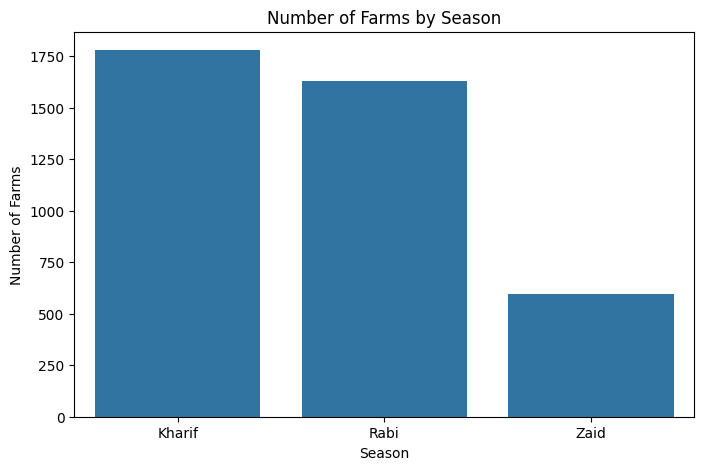

In [ ]:

season_counts = df['Season'].value_counts()

print(season_counts)

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Season')
plt.title('Number of Farms by Season')
plt.xlabel('Season')
plt.ylabel('Number of Farms')
plt.show()

**13.Average Yield by season**

,Yield_Tonnes_Ha
Season,
Kharif,5.628612
Rabi,5.039435
Zaid,4.641313


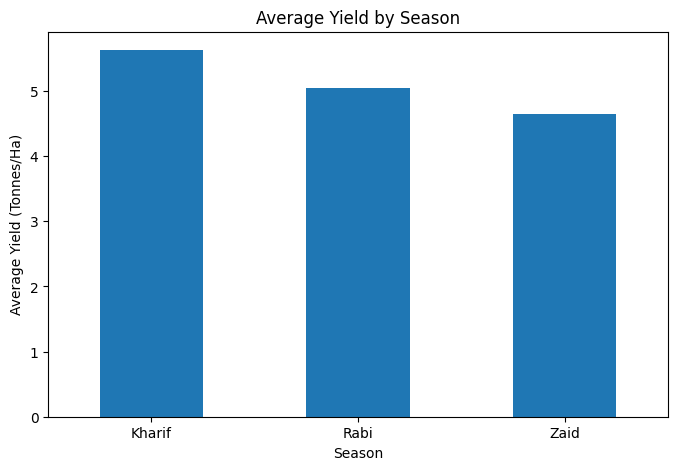

In [ ]:

season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

display(season_yield)

plt.figure(figsize=(8,5))
season_yield.plot(kind='bar')
plt.title('Average Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=0)
plt.show()

**14.Average Production by Season**

,Production_Tonnes
Season,
Kharif,46.311192
Rabi,41.486712
Zaid,38.886111


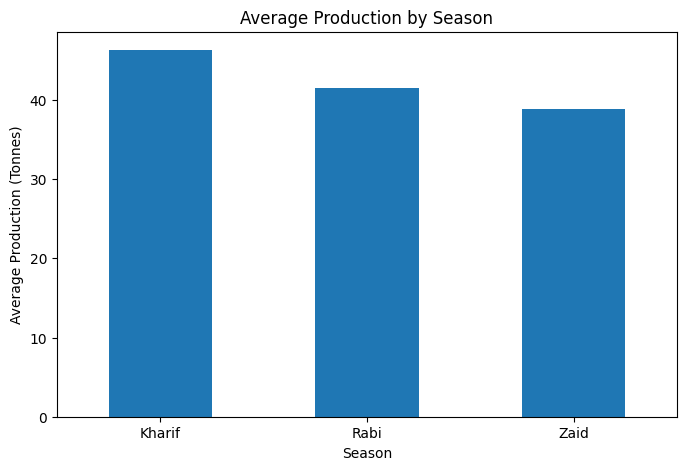

In [ ]:

season_production = df.groupby('Season')['Production_Tonnes'].mean().sort_values(ascending=False)

display(season_production)

plt.figure(figsize=(8,5))
season_production.plot(kind='bar')
plt.title('Average Production by Season')
plt.xlabel('Season')
plt.ylabel('Average Production (Tonnes)')
plt.xticks(rotation=0)
plt.show()

**15.Profit Comparison**

,Profit_INR
Season,
Kharif,178914.647555
Rabi,87689.470191
Zaid,-24804.824916


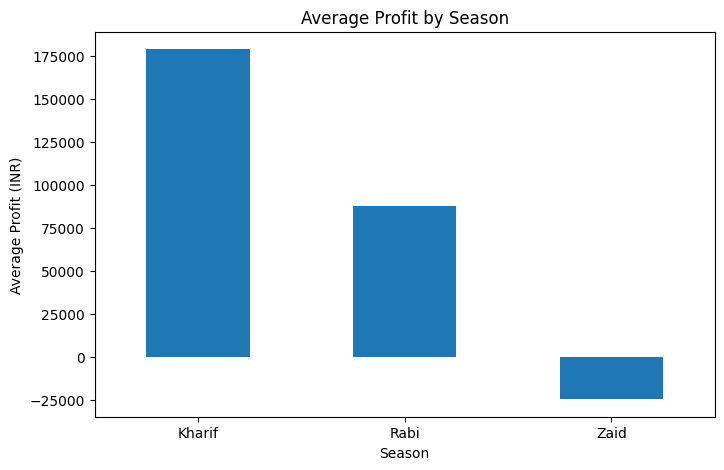

In [ ]:

season_profit = df.groupby('Season')['Profit_INR'].mean().sort_values(ascending=False)

display(season_profit)

plt.figure(figsize=(8,5))
season_profit.plot(kind='bar')
plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=0)
plt.show()

**16.Revenue cost by season**

,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,
Kharif,531804.408094,710719.055649,178914.647555
Rabi,513836.578365,601526.048556,87689.470191
Zaid,543976.728956,519171.904040,-24804.824916


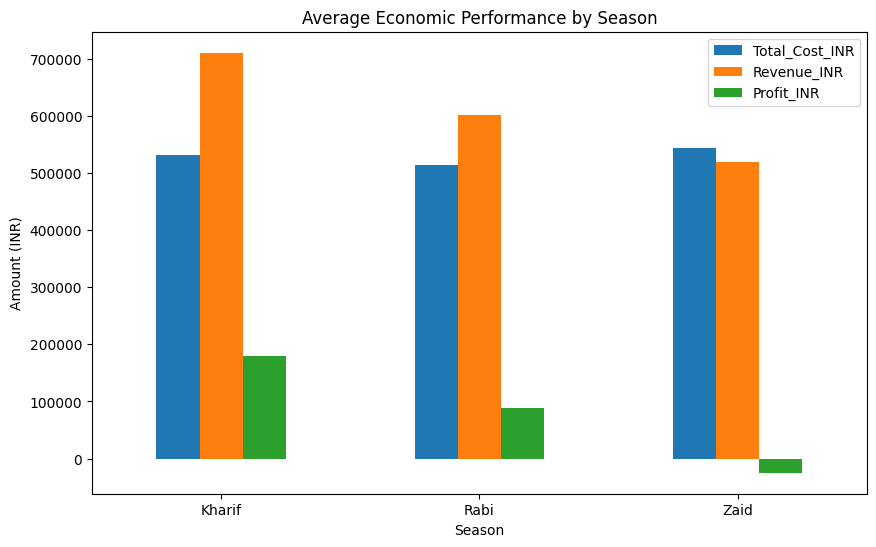

In [ ]:

economic = df.groupby('Season')[[
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR'
]].mean()

display(economic)

economic.plot(kind='bar', figsize=(10,6))
plt.title('Average Economic Performance by Season')
plt.xlabel('Season')
plt.ylabel('Amount (INR)')
plt.xticks(rotation=0)
plt.show()

**17.Rainfall and temperature by season**

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,849.199663,28.454019,71.812591,6.793367,31.149859
Rabi,437.615366,23.489183,57.893178,7.589797,24.069392
Zaid,304.654714,31.042088,52.012121,8.178788,19.279630


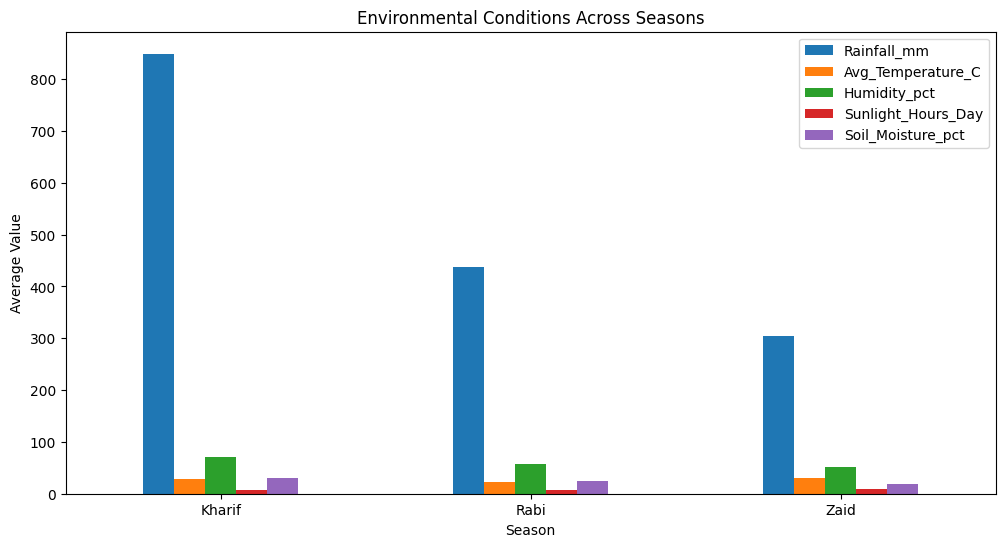

In [ ]:

environment = df.groupby('Season')[[
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_Moisture_pct'
]].mean()

display(environment)

environment.plot(kind='bar', figsize=(12,6))
plt.title('Environmental Conditions Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.show()

**18.Resources usage by season**

,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3
Season,,,
Kharif,187.077965,5.079747,6102.201237
Rabi,185.407068,5.024690,5846.987093
Zaid,184.638047,5.171212,6419.893939


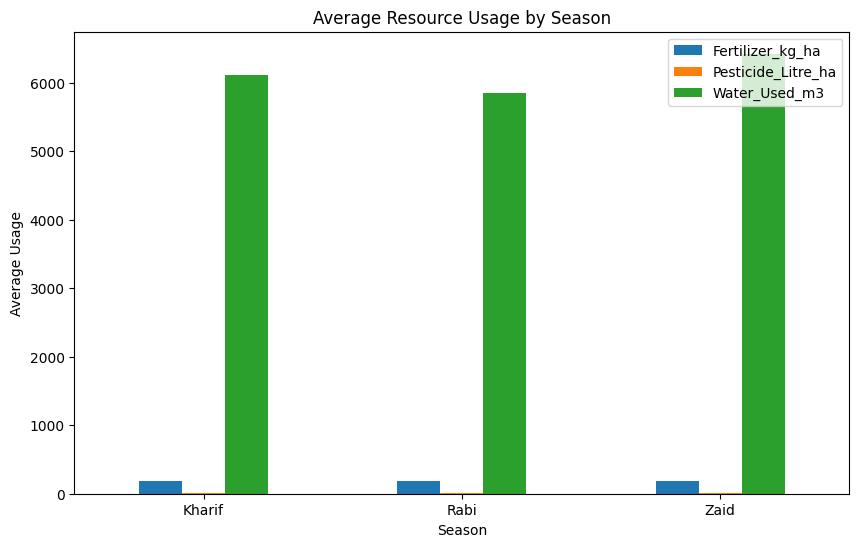

In [ ]:

resources = df.groupby('Season')[[
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Water_Used_m3'
]].mean()

display(resources)

resources.plot(kind='bar', figsize=(10,6))
plt.title('Average Resource Usage by Season')
plt.xlabel('Season')
plt.ylabel('Average Usage')
plt.xticks(rotation=0)
plt.show()

**19.Water efficiency**

,Water_Efficiency_t_per_1000m3
Season,
Kharif,5.891834
Rabi,5.186122
Zaid,4.413239


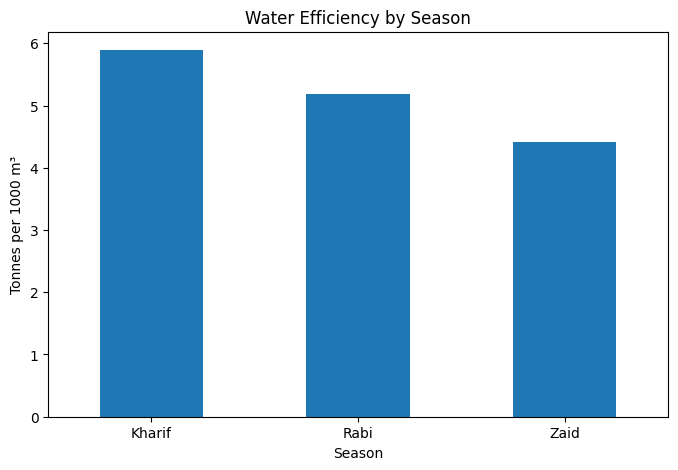

In [ ]:

water_efficiency = df.groupby('Season')['Water_Efficiency_t_per_1000m3'].mean()

display(water_efficiency)

plt.figure(figsize=(8,5))
water_efficiency.plot(kind='bar')
plt.title('Water Efficiency by Season')
plt.xlabel('Season')
plt.ylabel('Tonnes per 1000 m³')
plt.xticks(rotation=0)
plt.show()

**20.Disease peast risk**

,Disease_Pest_Risk_pct
Season,
Kharif,54.467903
Rabi,40.482114
Zaid,38.216667


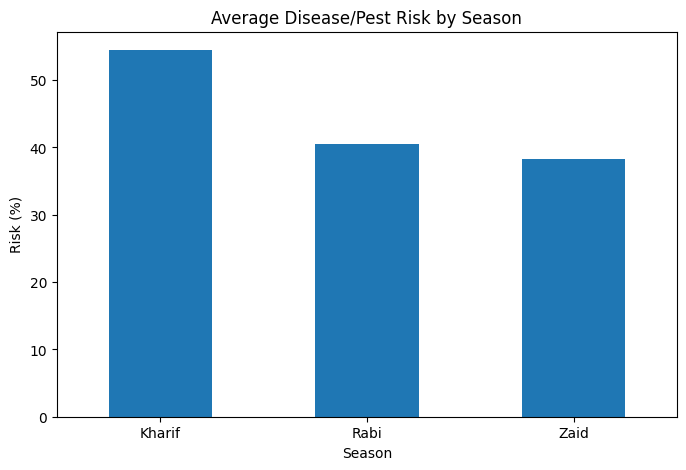

In [ ]:

risk = df.groupby('Season')['Disease_Pest_Risk_pct'].mean().sort_values(ascending=False)

display(risk)

plt.figure(figsize=(8,5))
risk.plot(kind='bar')
plt.title('Average Disease/Pest Risk by Season')
plt.xlabel('Season')
plt.ylabel('Risk (%)')
plt.xticks(rotation=0)
plt.show()

**21.Crop wise seasonal analysis**

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.731459,1.465031,1.195312
Cotton,1.374512,1.198358,0.960217
Groundnut,1.484974,1.233164,1.037778
Maize,2.966410,2.603648,2.290952
Pulses,1.036063,0.875962,0.669677
Rice,2.698376,2.322847,1.900490
Sugarcane,53.459120,43.286124,38.423922
Wheat,2.253664,2.057468,1.748588


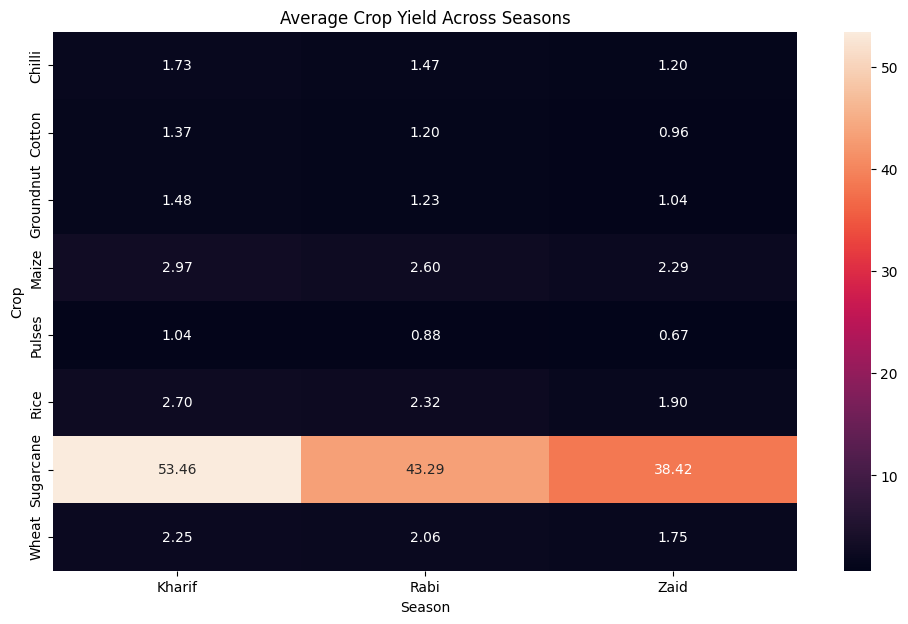

In [ ]:

crop_season = pd.pivot_table(
    df,
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

display(crop_season)

plt.figure(figsize=(12,7))
sns.heatmap(crop_season, annot=True, fmt='.2f')
plt.title('Average Crop Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('Crop')
plt.show()

**22.Irrigation method analysis**

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,405,590,463,321
Rabi,370,526,438,293
Zaid,140,194,140,120


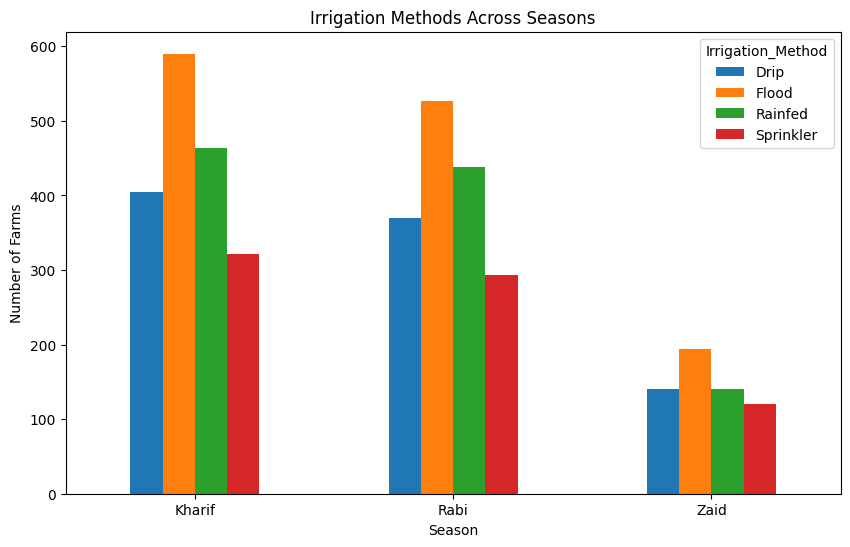

In [ ]:

irrigation = pd.crosstab(
    df['Season'],
    df['Irrigation_Method']
)

display(irrigation)

irrigation.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Irrigation Methods Across Seasons')
plt.xlabel('Season')
plt.ylabel('Number of Farms')
plt.xticks(rotation=0)
plt.show()

**23.Sead quality vs yield**

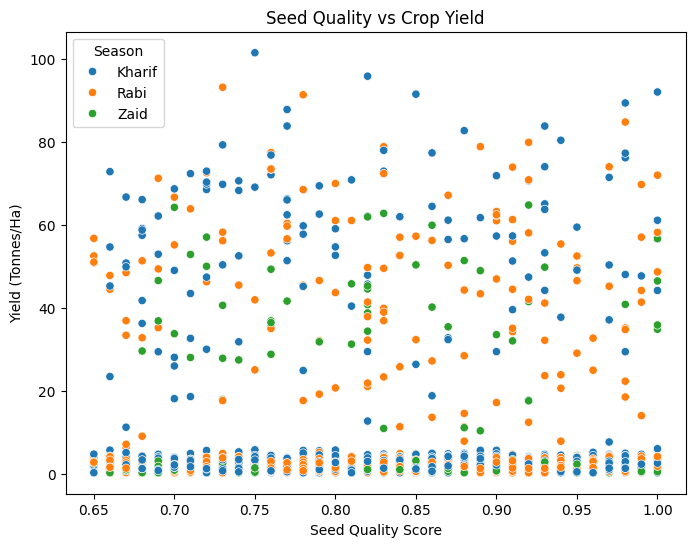

In [ ]:

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Seed_Quality_Score',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Seed Quality vs Crop Yield')
plt.xlabel('Seed Quality Score')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

**24.Rainfall vs yield**

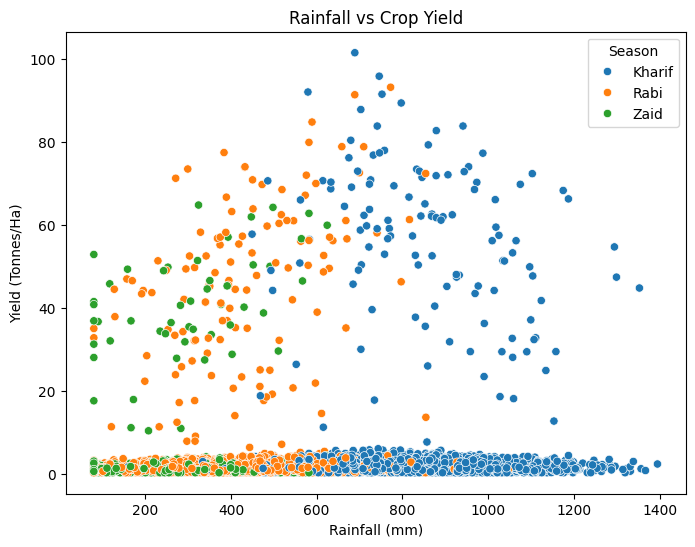

In [ ]:

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Rainfall vs Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

**25.Correalation analysis**

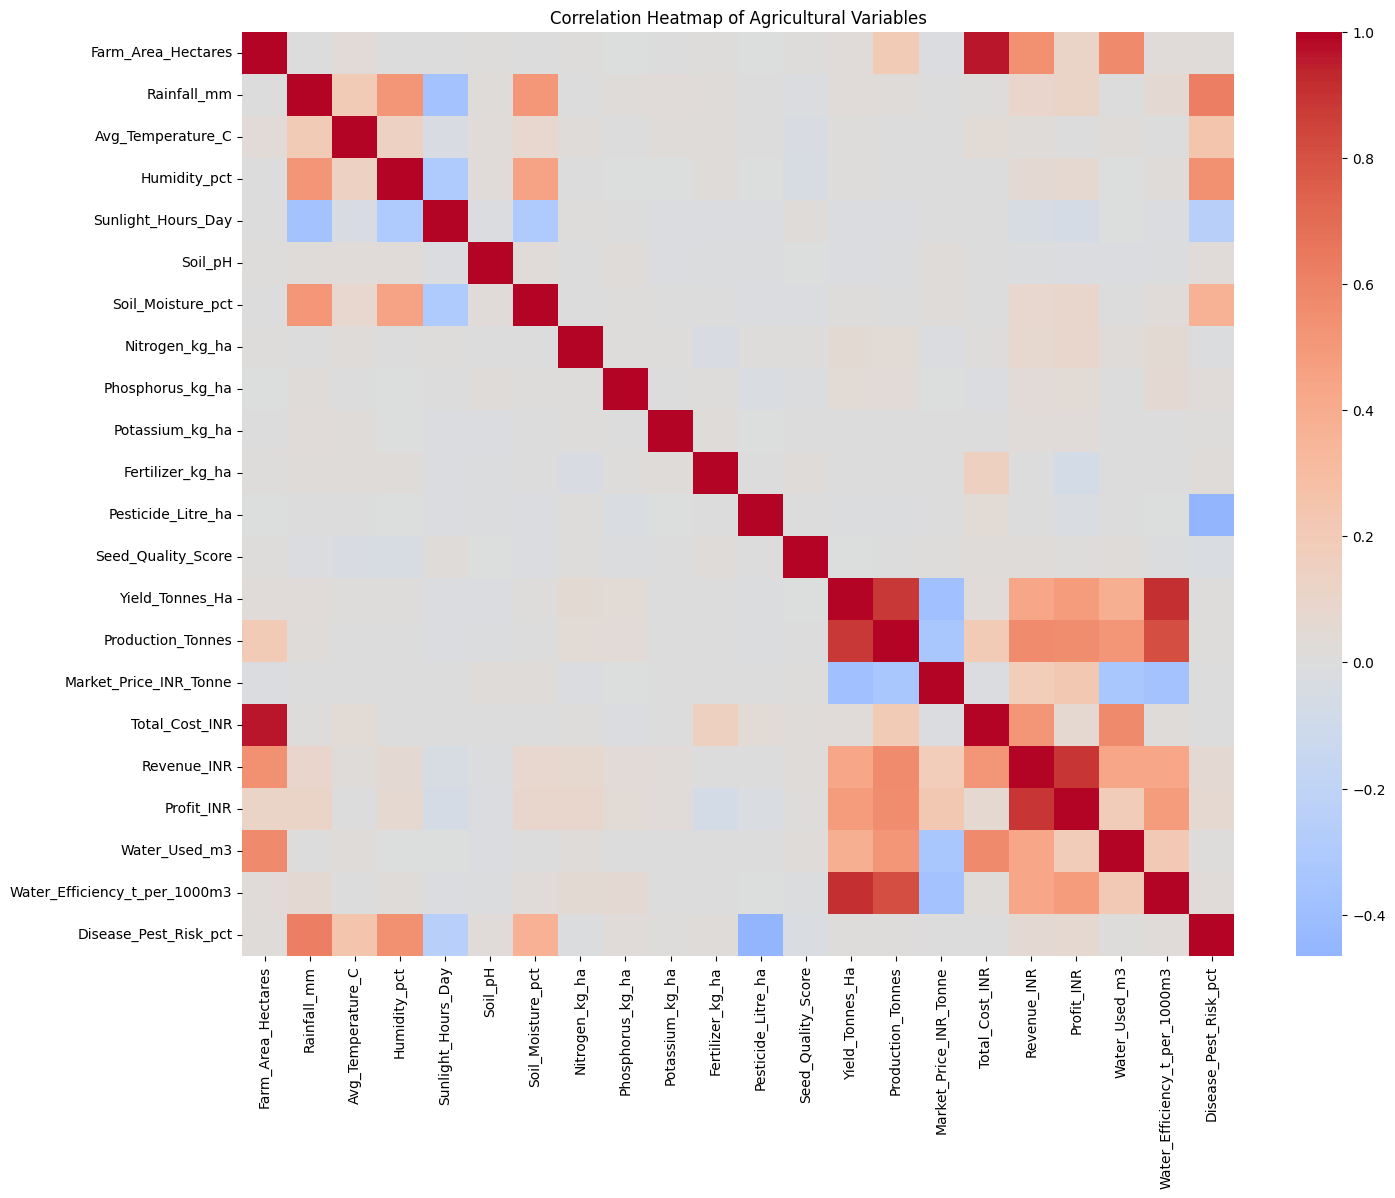

In [ ]:

numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(16,12))

sns.heatmap(
    correlation,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap of Agricultural Variables')
plt.show()

**26.Important Correlation with Yield**

In [ ]:

yield_corr = correlation['Yield_Tonnes_Ha'].sort_values(ascending=False)

print("Variables correlated with Yield:")
display(yield_corr)

Variables correlated with Yield:


,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000000
Water_Efficiency_t_per_1000m3,0.912568
Production_Tonnes,0.882813
Profit_INR,0.488466
Revenue_INR,0.432152
Water_Used_m3,0.386294
Nitrogen_kg_ha,0.053149
Phosphorus_kg_ha,0.047941
Rainfall_mm,0.030951
Total_Cost_INR,0.030622


**27.Best Season**

In [ ]:

best_yield_season = season_yield.idxmax()
best_profit_season = season_profit.idxmax()
best_water_season = water_efficiency.idxmax()

print("Best season based on average yield:", best_yield_season)
print("Best season based on average profit:", best_profit_season)
print("Best season based on water efficiency:", best_water_season)

Best season based on average yield: Kharif
Best season based on average profit: Kharif
Best season based on water efficiency: Kharif


**28.Best crop**

In [ ]:

crop_yield = df.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

print("Average Yield by Crop:")
display(crop_yield)

print("\nHighest yielding crop:", crop_yield.idxmax())
print("Highest average yield:", round(crop_yield.max(), 2), "Tonnes/Ha")

Average Yield by Crop:


,Yield_Tonnes_Ha
Crop,
Sugarcane,46.642361
Maize,2.710036
Rice,2.431304
Wheat,2.108013
Chilli,1.542767
Groundnut,1.322901
Cotton,1.229783
Pulses,0.921512



Highest yielding crop: Sugarcane
Highest average yield: 46.64 Tonnes/Ha


**29.Set wise performance**

In [ ]:

state_performance = df.groupby('State').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Profit_INR': 'mean'
}).sort_values('Yield_Tonnes_Ha', ascending=False)

display(state_performance.head(10))

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR
State,,,
Punjab,6.121116,52.233099,136025.636364
Karnataka,5.685481,47.732720,119422.335378
Gujarat,5.659016,48.331988,117568.235656
Telangana,5.044477,39.254186,108829.616279
Maharashtra,5.017480,43.984043,135428.855469
Madhya Pradesh,4.989940,37.559517,86840.756539
Tamil Nadu,4.875175,40.840371,117744.748454
Andhra Pradesh,4.628771,36.913157,73453.527410


**30.Top performance Farms**

In [ ]:

top_farms = df.sort_values(
    'Profit_INR',
    ascending=False
)[[
    'Farm_ID',
    'State',
    'District',
    'Crop',
    'Season',
    'Yield_Tonnes_Ha',
    'Revenue_INR',
    'Profit_INR'
]].head(10)

display(top_farms)

,Farm_ID,State,District,Crop,Season,Yield_Tonnes_Ha,Revenue_INR,Profit_INR
2236,SF12237,Punjab,Rajkot,Chilli,Kharif,3.90,5057448,4345421
626,SF10627,Maharashtra,Warangal,Chilli,Kharif,2.92,5080900,4021850
3425,SF13426,Madhya Pradesh,Rajkot,Sugarcane,Kharif,82.68,4485260,3740099
1690,SF11691,Karnataka,Warangal,Chilli,Kharif,3.01,4522464,3738329
247,SF10248,Maharashtra,Krishna,Chilli,Kharif,3.09,4825365,3542204
357,SF10358,Punjab,Warangal,Sugarcane,Rabi,84.75,4350998,3378879
3423,SF13424,Andhra Pradesh,Indore,Sugarcane,Kharif,95.79,4428460,3330582
1930,SF11931,Tamil Nadu,Guntur,Sugarcane,Kharif,79.25,4108301,3232970
3983,SF13984,Gujarat,Nashik,Chilli,Kharif,3.02,4055609,3211345
263,SF10264,Maharashtra,Ludhiana,Chilli,Rabi,2.53,3987664,3159447


**31.Automatically generate project findings**

In [ ]:

print("========== PROJECT FINDINGS ==========\n")

print("1. Best season based on average yield:")
print(best_yield_season)

print("\n2. Best season based on average profit:")
print(best_profit_season)

print("\n3. Best season based on water efficiency:")
print(best_water_season)

print("\n4. Highest yielding crop:")
print(crop_yield.idxmax())

print("\n5. Highest average crop yield:")
print(round(crop_yield.max(), 2), "Tonnes/Ha")

print("\n6. Number of farms analyzed:")
print(len(df))

print("\n7. Number of crops:")
print(df['Crop'].nunique())

print("\n8. Number of seasons:")
print(df['Season'].nunique())

print("\n9. Number of states:")
print(df['State'].nunique())

========== PROJECT FINDINGS ==========

1. Best season based on average yield:
Kharif

2. Best season based on average profit:
Kharif

3. Best season based on water efficiency:
Kharif

4. Highest yielding crop:
Sugarcane

5. Highest average crop yield:
46.64 Tonnes/Ha

6. Number of farms analyzed:
4000

7. Number of crops:
8

8. Number of seasons:
3

9. Number of states:
8


**32.Final Conclusion**

In [ ]:

print("""
CONCLUSION

The Seasonal Agriculture Performance Analysis examined agricultural
performance across different seasons using environmental, resource,
production and economic variables.

The analysis compared seasons based on crop yield, production,
profit, rainfall, temperature, resource usage, water efficiency
and disease/pest risk.

Seasonal differences were observed in agricultural performance.
The results help identify important seasonal patterns and
relationships between environmental conditions, farming practices
and agricultural outcomes.

The analysis can support evidence-based agricultural planning by
helping farmers and stakeholders understand seasonal performance,
resource usage and economic outcomes.
""")


CONCLUSION

The Seasonal Agriculture Performance Analysis examined agricultural
performance across different seasons using environmental, resource,
production and economic variables.

The analysis compared seasons based on crop yield, production,
profit, rainfall, temperature, resource usage, water efficiency
and disease/pest risk.

Seasonal differences were observed in agricultural performance.
The results help identify important seasonal patterns and
relationships between environmental conditions, farming practices
and agricultural outcomes.

The analysis can support evidence-based agricultural planning by
helping farmers and stakeholders understand seasonal performance,
resource usage and economic outcomes.



**33.Save the cleaned data**

In [ ]:

df.to_csv(
    'cleaned_seasonal_agriculture_dataset.csv',
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


**34.Download Cleaned dataset**

In [ ]:

from google.colab import files

files.download('cleaned_seasonal_agriculture_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>